In [2]:
import os, sys 
from pathlib import Path
from os.path import dirname, realpath
script_dir = Path(dirname(realpath('.')))
module_dir = str(script_dir)
sys.path.insert(0, module_dir + '/modules')
import numpy as np
import utility as ut
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from scipy import stats
import seaborn as sns
import oneshot as sm
import rfm, skipRFM, deepSkip, localSkip_2_2, localDeepSkip_8_1, localDeepSkip_2_2, localSkip_8_1, localSkip81, localSkip_16_1
# import parallel_euler as arch1
import torch, time
from torch import nn
import ks, l63, l96, ks_torch, ks0
import config

def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
kwargs = {200:{'error_threshold': 0.25, 'dt': 0.25, 'Lyapunov_time': 1/0.094},\
          22:{'error_threshold' : 0.25, 'dt': 0.25, 'Lyapunov_time': 1/0.043},\
          12:{'error_threshold' : 0.25, 'dt': 0.25, 'Lyapunov_time': 1/0.003}}
dynamical_system = 'KS'
L = 12
folder = f'../data/KS-{L}'
Uo = torch.tensor(np.load(f'../data/{dynamical_system}-{L}/train.npy'))[:,:100000]
Vo = torch.tensor(np.load(f'../data/{dynamical_system}-{L}/test.npy'))
ut.gather_beta(f'KS-{L}')

Working on ../data/KS-12/config_test_12/LocalSkip_8_1/beta ...
../data/KS-12/config_test_12/LocalSkip_8_1/beta/beta_D_r-2048_B-1.csv 2048 1
Working on ../data/KS-12/config_test_12/LocalSkip_12_1/beta ...
../data/KS-12/config_test_12/LocalSkip_12_1/beta/beta_D_r-2048_B-1.csv 2048 1
Working on ../data/KS-12/config_test_12/SkipRFM/beta ...
../data/KS-12/config_test_12/SkipRFM/beta/beta_D_r-2048_B-1.csv 2048 1


**beta vs VPT**

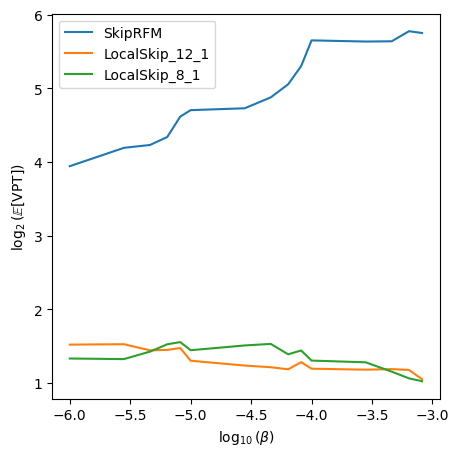

In [17]:
config = 'config_test_12'
D_r, B, n = 2048, 1, 10
data_folder = f"{folder}/{config}"
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
for architecture in ['SkipRFM', 'LocalSkip_12_1', 'LocalSkip_8_1']:
    data = pd.read_csv(f'{data_folder}/{architecture}/beta/beta_D_r-{D_r}_B-{B}.csv')
    x, y = data['beta'], data['tau_f_nmse_mean']
    x_ = np.log10(x[n:-n])
    y_ = np.log2(smooth(y, n)[n:-n])
    ax.plot(x_, y_, label=f'{architecture}')
    ax.set_xlabel(r'$\log_{10}(\beta)$')
    ax.set_ylabel(r'$\log_{2}(\mathbb{E}[\text{VPT}])$')
ax.legend()
plt.savefig(f"../data/plots/KS-12-beta-vs-VPT.png", bbox_inches="tight", dpi=300)

**Covariance structure**

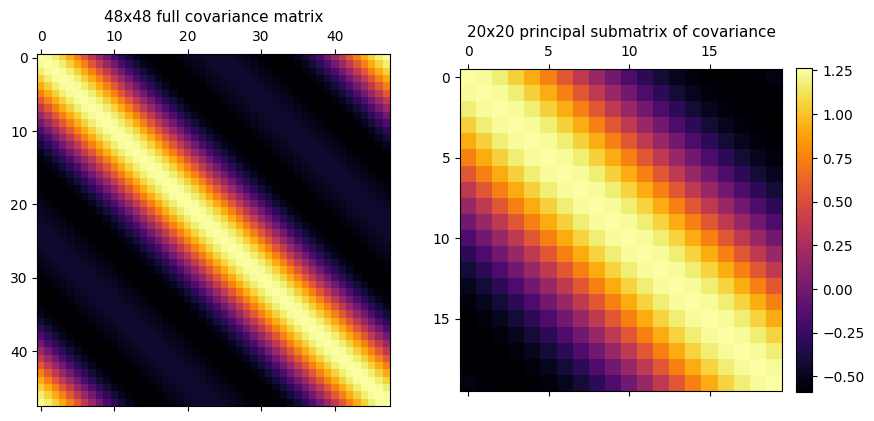

In [4]:
cov = np.cov(Uo)
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(121)
ax1 = fig.add_subplot(122)
ax.matshow(cov, cmap='inferno')
im = ax1.matshow(cov[:20, :20], cmap='inferno')
ax.set_title("48x48 full covariance matrix", fontsize=11)
ax1.set_title("20x20 principal submatrix of covariance", fontsize=11)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.savefig(f"../data/plots/KS-12-cov.png", bbox_inches="tight", dpi=300)

**Forecast times**

112.49925
12.624
9.26925


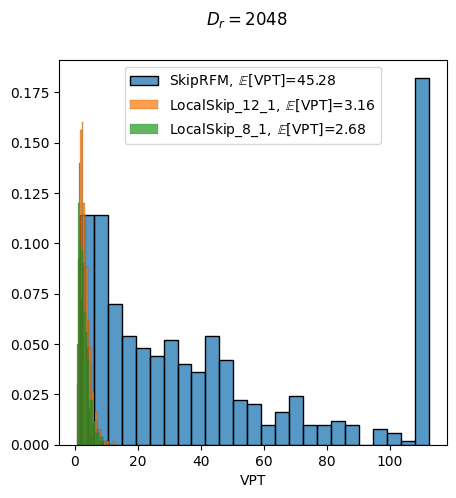

In [33]:
config = 'config_test_12'
D_r, B, n = 2048, 1, 10
data_folder = f"{folder}/{config}"
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
# ax1 = fig.add_subplot(122)
for architecture in ['SkipRFM', 'LocalSkip_12_1', 'LocalSkip_8_1']:
    data = pd.read_csv(f'{data_folder}/{architecture}/D_r-{D_r}_B-{B}/batch_data.csv')
    print(data['tau_f_nmse'].max())
    sns.histplot(data['tau_f_nmse'], ax=ax, label=f"{architecture}" + r'$,\;\mathbb{E}[{\rm VPT}]$' + f"={data['tau_f_nmse'].mean():.2f}", bins=25, stat='probability')
    # sns.histplot(data['tau_f_se'], ax=ax1, label=f"{architecture}" + r'$,\;\mathbb{E}[{\tau_f}]$' + f"={data['tau_f_se'].mean():.2f}", bins=25, stat='probability')
ax.set_xlabel(r'VPT')
# ax1.set_xlabel(r'$\tau_f$')
ax.set_ylabel('')
# ax1.set_ylabel('')
ax.legend()
# ax1.legend()
fig.suptitle(f'$D_r=${D_r}')
plt.savefig(f"../data/plots/KS-12-vpt.png", bbox_inches="tight", dpi=300)

**train and test data**

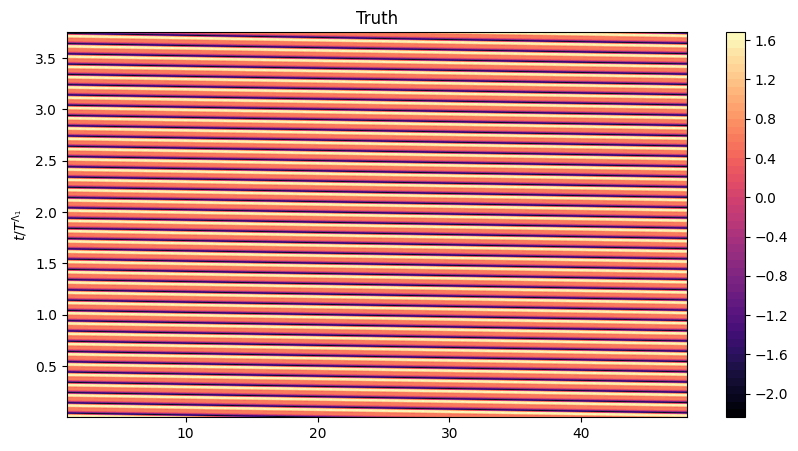

In [4]:
i = np.random.randint(100000-1000)
ut.waterfall(Uo[:, i:i+5000], filename=f"KS-{L}-train-partial", levels=50,  **kwargs[L])

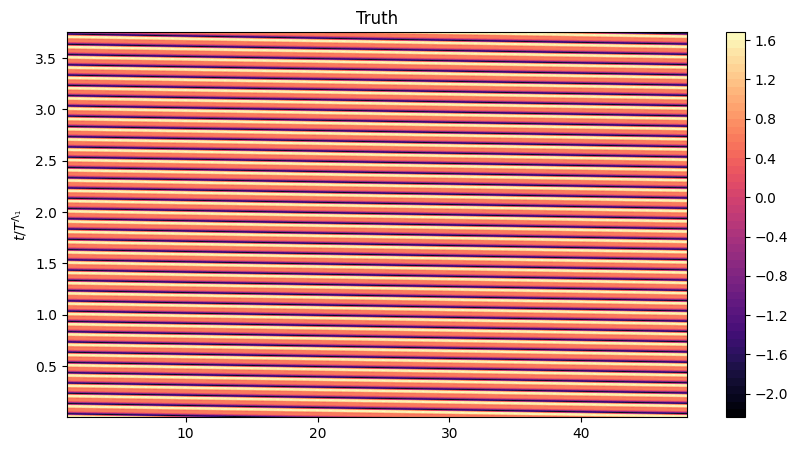

In [5]:
i = np.random.randint(100000-1000)
ut.waterfall(Vo[0][:, i:i+5000], filename=f"KS-{L}-test-partial", levels=50,  **kwargs[L])